# Chapter 4 - The Recommendation Engine

Chapter 3 established what the cleaned dataset looks like: about 14,800 tracks by 5,100
artists, roughly 85,000 positive reactions from about 1,300 users, and a user-track
matrix that is 0.55% dense. This chapter is about what was built on top of that, and it
covers three things:

1. **How the engine works.** The two-stage ensemble that ships in `engine_v2/` - what
   each model learns, how the training data is assembled, and how a recommendation is
   produced at request time.
2. **How it is served.** A standalone FastAPI microservice on loopback, deployed
   independently of the main application.
3. **What is wrong with it.** A review of the pipeline produced roughly thirty findings,
   the significant ones documented here with the evidence. The revised engine lives in
   `engine RND/`, and its full write-up is in
   [`engine RND/ANALYSIS.md`](../engine%20RND/ANALYSIS.md).

Everything numeric below is computed in this notebook from the trained artifacts
committed under `engine_v2/model_params/`. Figures that come from the training
notebooks' recorded output are labelled as such, because those runs cannot be reproduced
here - a point section 4.10 returns to.

In [1]:
import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PARAMS_DIR = Path("../engine_v2/model_params")
ENGINE_RND = Path("../engine RND")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})
INK, ACCENT, SECOND = "#334155", "#4F46E5", "#0E7490"
POSITIVE, NEGATIVE, MUTED = "#15803D", "#B91C1C", "#94A3B8"

## 4.0 Reading the artifacts

The engine's twelve model files include four pickled scikit-learn `LabelEncoder`
objects. Only one attribute of each is ever used - `classes_`, a plain integer array
mapping a model row back to a real id - so rather than take a dependency on the exact
scikit-learn version that wrote them, the loader below substitutes a stub class during
unpickling and reads the array out directly.

That is a small thing, but it is the first hint of a recurring theme in this chapter:
several of this pipeline's costs are incidental rather than essential.

In [2]:
class _StubEstimator:
    """Stand-in for sklearn.preprocessing.LabelEncoder during unpickling."""


class _StubUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("sklearn"):
            return _StubEstimator
        return super().find_class(module, name)


def load_classes(path: Path) -> np.ndarray:
    """Read LabelEncoder.classes_ without importing scikit-learn."""
    with path.open("rb") as fh:
        return np.asarray(_StubUnpickler(fh).load().classes_, dtype=np.int64)


def load_plain(path: Path):
    with path.open("rb") as fh:
        return pickle.load(fh)


config = json.loads((PARAMS_DIR / "ensemble_config.json").read_text())

user_ids_artist = load_classes(PARAMS_DIR / "user_enc_artist.pkl")
user_ids_track = load_classes(PARAMS_DIR / "track_user_enc.pkl")
artist_ids = load_classes(PARAMS_DIR / "artist_enc.pkl")
track_ids_scored = load_classes(PARAMS_DIR / "track_item_enc.pkl")

track_to_artist = load_plain(PARAMS_DIR / "track_to_artist.pkl")
track_id_to_idx = load_plain(PARAMS_DIR / "track_id_to_idx.pkl")

track_pop = np.load(PARAMS_DIR / "track_pop.npy")
artist_user_emb = np.load(PARAMS_DIR / "artist_user_embeddings.npy")
artist_item_emb = np.load(PARAMS_DIR / "artist_artist_embeddings.npy")
track_user_emb = np.load(PARAMS_DIR / "track_user_embeddings.npy")
track_item_emb = np.load(PARAMS_DIR / "track_item_embeddings.npy")

print("ensemble_config.json:")
for key, value in config.items():
    print(f"  {key:32} {value}")
print()
print(f"artist model: {artist_user_emb.shape[0]:,} users x {artist_item_emb.shape[0]:,} "
      f"artists, dim {artist_item_emb.shape[1]}")
print(f"track model:  {track_user_emb.shape[0]:,} users x {track_item_emb.shape[0]:,} "
      f"tracks,  dim {track_item_emb.shape[1]}")
print(f"catalogue:    {len(track_to_artist):,} tracks, "
      f"{len(track_id_to_idx):,} with at least one positive reaction")

ensemble_config.json:
  artist_embedding_dim             200
  track_embedding_dim              100
  n_users_artist                   1310
  n_artists                        5107
  genre_dim                        373
  n_artists_candidates             20
  tracks_per_artist_candidate      10
  top_k_final                      10

artist model: 1,310 users x 5,107 artists, dim 200
track model:  1,239 users x 12,433 tracks,  dim 100
catalogue:    14,843 tracks, 12,433 with at least one positive reaction


## 4.1 Why not just factorise the user-track matrix?

The obvious approach is matrix factorisation directly on user-track interactions. It
does not work well here, and the reason is visible in one number: the median track has
four positive reactions.

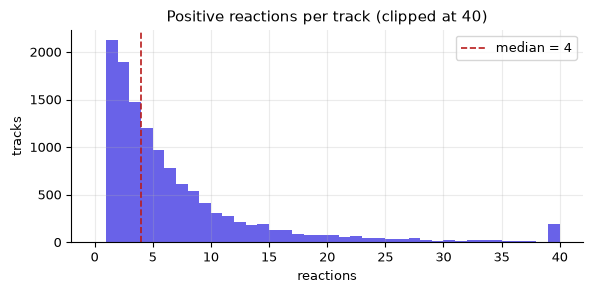

tracks with <= 2 reactions: 4,018 (32.3%)
mean positive reactions per user: 68.4


In [3]:
per_track = track_pop
per_user = per_track.sum() / len(user_ids_track)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(np.clip(per_track, 0, 40), bins=np.arange(0, 41, 1), color=ACCENT, alpha=0.85)
ax.axvline(np.median(per_track), color=NEGATIVE, linestyle="--", linewidth=1.2,
           label=f"median = {np.median(per_track):.0f}")
ax.set_title("Positive reactions per track (clipped at 40)")
ax.set_xlabel("reactions")
ax.set_ylabel("tracks")
ax.legend()
plt.tight_layout()
plt.show()

print(f"tracks with <= 2 reactions: {(per_track <= 2).sum():,} ({(per_track <= 2).mean():.1%})")
print(f"mean positive reactions per user: {per_user:.1f}")

A latent vector of dimension 100 fitted from two observations is not an estimate, it is
noise. Almost a third of the catalogue is in that position.

Artist-level signal is denser, because a single artist aggregates the reactions of all
their tracks. That is the entire premise of the design: **learn taste at the artist
level, where there is enough data, and use the track model only to choose between a
handful of candidates already known to be plausible.**

In [4]:
artist_of_track = np.array([track_to_artist.get(int(t), -1) for t in track_ids_scored])
by_artist = {}
for artist, pop in zip(artist_of_track, track_pop):
    if artist != -1:
        by_artist[artist] = by_artist.get(artist, 0.0) + float(pop)
artist_reaction_totals = np.array(list(by_artist.values()))

def profile(values, label):
    values = np.asarray(values, dtype=float)
    learnable = values >= 10          # enough observations to fit a 100-dim vector
    return {
        "level": label,
        "entities to model": f"{len(values):,}",
        "mean reactions": f"{values.mean():.1f}",
        "median": f"{np.median(values):.0f}",
        "share of entities with >= 10": f"{learnable.mean():.1%}",
        "share of signal on those": f"{values[learnable].sum() / values.sum():.1%}",
    }

rows = [profile(track_pop, "track"), profile(artist_reaction_totals, "artist")]
width = max(len(k) for k in rows[0])
for key in rows[0]:
    print(f"{key:<{width}}  {rows[0][key]:>12}  {rows[1][key]:>12}")

level                                track        artist
entities to model                   12,433         3,545
mean reactions                         6.8          23.4
median                                   4             4
share of entities with >= 10         19.6%         28.2%
share of signal on those             56.5%         89.8%


The medians are identical, and that is not a mistake: 65% of artists have exactly one
track (Chapter 3, B.4), so a single-track artist simply inherits its track's count and
the middle of the distribution does not move.

The gain is in the mean and in where the signal lands. Aggregation cuts the number of
entities to model by roughly two thirds while raising the average observation count by
about 3.5x, and the share of all reactions falling on an entity with at least ten
observations rises substantially. Those are the entities a latent factor model can
actually fit - and they are also the artists people mostly react to. The long tail of
one-track artists is no better served at the artist level than at the track level, which
is worth remembering: the architecture makes the head learnable, it does not make the
tail disappear.

## 4.2 The two-stage architecture

```mermaid
flowchart TB
    subgraph TRAIN["Training (engine_v2/engine_newer.ipynb)"]
        R["Positive track reactions<br/>score &gt; 1.0, weighted"] --> UA
        AR["Artist-message reactions"] --> UA
        UP["Uploads, weight 5.0 each"] --> UA
        UA["User-artist matrix<br/>weighted, sparse"] --> AUG["+ synthetic related-artist edges<br/>weight 0.2"]
        AUG --> M1["HybridArtistMF<br/>weighted BPR + edge loss"]
        GEN["Genre matrix<br/>5107 x 373 binary"] --> M1
        R --> UT["User-track matrix<br/>binary"] --> M2["TrackMF<br/>plain BPR"]
    end

    subgraph SERVE["Serving (engine_v2/recommender.py)"]
        M1 -.exported embeddings.-> S1["Stage 1<br/>rank all 5,107 artists<br/>keep top N"]
        S1 --> S2["Stage 2a<br/>collect unseen tracks<br/>from those artists"]
        M2 -.exported embeddings.-> S3["Stage 2b<br/>re-rank candidates"]
        S2 --> S3 --> OUT["Top K track ids"]
    end
```

Stage 1 answers "whose music does this person like?" from the denser signal. Stage 2
answers "which of these particular tracks?" from the sparser signal, but only ever has
to compare a few dozen candidates rather than 12,433 - which is precisely the regime in
which a noisy model is still useful.

## 4.3 Stage 1: `HybridArtistMF`

A matrix factorisation model with a content-based side channel:

```python
class HybridArtistMF(nn.Module):
    def __init__(self, n_users, n_artists, emb_dim, genre_dim):
        self.user_emb      = nn.Embedding(n_users, emb_dim)      # 1310 x 200
        self.artist_id_emb = nn.Embedding(n_artists, emb_dim)    # 5107 x 200
        self.genre_proj    = nn.Linear(genre_dim, emb_dim, bias=False)  # 373 -> 200
        self.user_bias     = nn.Embedding(n_users, 1)
        self.artist_bias   = nn.Embedding(n_artists, 1)

    def forward(self, user_idx, artist_idx, genre_features):
        a = self.artist_id_emb(artist_idx) + self.genre_proj(genre_features[artist_idx])
        return (self.user_emb(user_idx) * a).sum(-1) \
               + self.user_bias(user_idx).squeeze(-1) \
               + self.artist_bias(artist_idx).squeeze(-1)
```

The important line is the composition of the artist representation:

```
artist_embedding = artist_id_emb + genre_proj(genre_features)
```

An artist with plenty of interactions is described mostly by their learned id
embedding. An artist with almost none has an id embedding close to its initialisation,
so their representation is carried by the genre projection instead. That is how the
model says anything at all about a cold-start artist, and it is the reason the genre
matrix from Chapter 3 exists.

Two losses are optimised together:

```
loss = weighted_BPR(user, positive_artist, sampled_negative, w)
       + REG_LAMBDA * mean((emb[a] - emb[b])**2 for related pairs (a, b))
```

The first is Bayesian Personalised Ranking, weighted so that a strong reaction or an
upload contributes more gradient than a mild one. The second pulls artists that Last.fm
considers related towards each other in the latent space.

### Verifying the composition against the shipped weights

The claim above is checkable. `artist_model_state.pt` holds the raw parameters and
`artist_artist_embeddings.npy` holds the composed result, so recomputing
`artist_id_emb + genre_proj(genre)` should reproduce the export exactly.

The state dicts are read here without importing torch, using the reader written for the
revised engine (`engine RND/tools/torch_pickle.py`) - a `.pt` file is a zip archive of
one pickle plus one binary blob per tensor, which is recoverable with the standard
library alone.

In [5]:
sys.path.insert(0, str(ENGINE_RND.resolve()))
from tools import torch_pickle

artist_state = torch_pickle.load(PARAMS_DIR / "artist_model_state.pt")
genre_features = torch_pickle.load(PARAMS_DIR / "genre_features.pt")

for name, tensor in artist_state.items():
    print(f"{name:22} {tensor.shape}")
print(f"{'genre_features':22} {genre_features.shape}")

recomposed = artist_state["artist_id_emb.weight"] + genre_features @ artist_state["genre_proj.weight"].T
print()
print("artist_id_emb + genre_proj(genre) == artist_artist_embeddings.npy :",
      np.array_equal(recomposed, artist_item_emb))

user_emb.weight        (1310, 200)
artist_id_emb.weight   (5107, 200)
genre_proj.weight      (200, 373)
user_bias.weight       (1310, 1)
artist_bias.weight     (5107, 1)
genre_features         (5107, 373)

artist_id_emb + genre_proj(genre) == artist_artist_embeddings.npy : True


Exact match, so the composition is confirmed and the raw parameters can be trusted.
Two observations follow immediately from them.

artist_bias: std 0.301, range [-0.80, 1.42]
user_bias:   std 0.000, range [0.00, 0.00]  <- all zeros

dot-product scores: std 1.206
artist_bias / score std: 25.0%


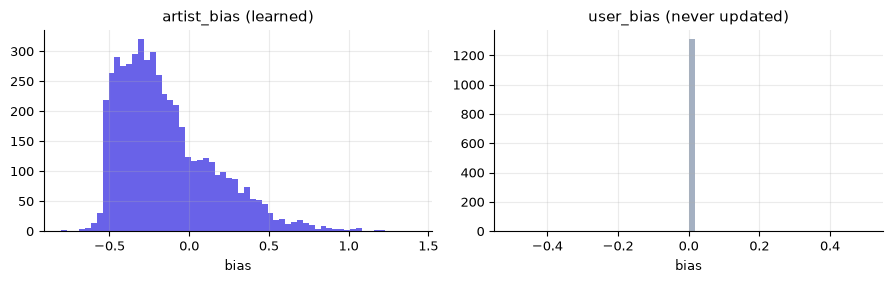

In [6]:
artist_bias = artist_state["artist_bias.weight"].reshape(-1)
user_bias = artist_state["user_bias.weight"].reshape(-1)

print(f"artist_bias: std {artist_bias.std():.3f}, range [{artist_bias.min():.2f}, "
      f"{artist_bias.max():.2f}]")
print(f"user_bias:   std {user_bias.std():.3f}, range [{user_bias.min():.2f}, "
      f"{user_bias.max():.2f}]  <- all zeros")
print()

# How large is the bias relative to the scores it is added to?
sample_scores = artist_user_emb[:200] @ artist_item_emb.T
print(f"dot-product scores: std {sample_scores.std():.3f}")
print(f"artist_bias / score std: {artist_bias.std() / sample_scores.std():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(9, 2.9))
axes[0].hist(artist_bias, bins=60, color=ACCENT, alpha=0.85)
axes[0].set_title("artist_bias (learned)")
axes[0].set_xlabel("bias")
axes[1].hist(user_bias, bins=60, color=MUTED, alpha=0.85)
axes[1].set_title("user_bias (never updated)")
axes[1].set_xlabel("bias")
plt.tight_layout()
plt.show()

**`user_bias` is dead weight.** It is exactly zero after 100 epochs, and that is
structural rather than accidental: BPR optimises the *difference* between a positive and
a negative score for the same user, and a per-user constant cancels in that difference.
It can never receive a gradient. Harmless, but it means nobody checked.

**`artist_bias` is not.** It carries about 30% of the standard deviation of the scores
it is added to, so it materially changes which artists come out on top. This matters
because of section 4.6.

## 4.4 Building the training data

Three positive signals are pooled into a single weighted user-artist matrix:

| source | weight |
|---|---|
| positive track reaction (`strength > 1.0`) | the reaction's strength, 2.0 to 5.0 |
| positive reaction on an artist message | same |
| uploading a track | fixed 5.0, credited to the track's artist |

Then synthetic interactions are injected: for every user who likes artist A, a
weight-0.2 edge is added to each of A's Last.fm-related artists that the user has not
already interacted with.

The recorded output of the training run in `engine_v2/engine_newer.ipynb`:

```
User-Artist matrix: 1285 users x 4919 artists, 59,959 interactions
Adding synthetic related-artist interactions...
After augmentation: 145,685 interactions
```

That is worth pausing on. **59% of every training epoch is synthetic data** derived from
Last.fm metadata rather than from anything a member of the group actually did. The same
related-artist information is *also* applied as the edge-regularisation loss, so it
enters the objective twice through two different mechanisms. Neither notebook contains
an ablation with the injection turned off, so its contribution is unmeasured.

### Unbounded interaction weights

Upload weight is added per uploaded track, with no cap and no compression. A user who
has uploaded many tracks by one artist accumulates a very large weight for that pair,
and since weights multiply the BPR loss directly (`(w * bpr).mean()`), a handful of
pairs can dominate the gradient.

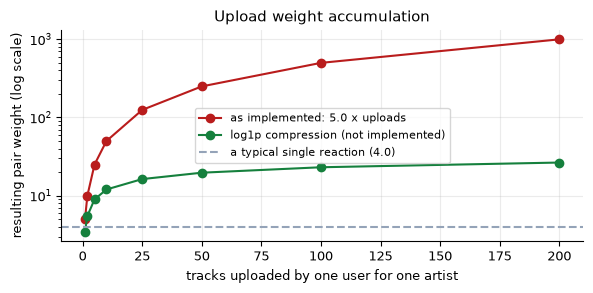

200 uploads -> weight 1,000, 250x a typical reaction pair


In [7]:
UPLOAD_WEIGHT = 5.0
uploads_per_artist = np.array([1, 2, 5, 10, 25, 50, 100, 200])
typical_reaction_pair = 4.0  # one strong reaction

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(uploads_per_artist, uploads_per_artist * UPLOAD_WEIGHT, "o-", color=NEGATIVE,
        label="as implemented: 5.0 x uploads")
ax.plot(uploads_per_artist, UPLOAD_WEIGHT * np.log1p(uploads_per_artist), "o-",
        color=POSITIVE, label="log1p compression (not implemented)")
ax.axhline(typical_reaction_pair, color=MUTED, linestyle="--",
           label="a typical single reaction (4.0)")
ax.set_yscale("log")
ax.set_xlabel("tracks uploaded by one user for one artist")
ax.set_ylabel("resulting pair weight (log scale)")
ax.set_title("Upload weight accumulation")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"200 uploads -> weight {200 * UPLOAD_WEIGHT:,.0f}, "
      f"{200 * UPLOAD_WEIGHT / typical_reaction_pair:,.0f}x a typical reaction pair")

Neither `log1p` compression nor a percentile clip is applied. Both are one-line changes
and both would bound the influence of a single prolific uploader.

One further detail in the same stage: `to_canonical_artist` takes
`str(artists_id).split(',')[0]` - the first artist only. Featured artists never enter
the user-artist matrix at all, which quietly undoes part of the featured-artist
extraction work described in Chapter 3.

## 4.5 Stage 2: `TrackMF`

Deliberately plain - no side features, no biases, standard BPR on the binary user-track
matrix:

```python
class TrackMF(nn.Module):
    def __init__(self, n_users, n_items, emb_dim):
        self.user_emb = nn.Embedding(n_users, emb_dim)   # 1239 x 100
        self.item_emb = nn.Embedding(n_items, emb_dim)   # 12433 x 100

    def forward(self, user, item):
        return (self.user_emb(user) * self.item_emb(item)).sum(-1)
```

Simplicity is appropriate here because this model is never asked to rank the catalogue.
It only ever orders a few dozen candidates that stage 1 has already vouched for.

Note the population difference: the artist model covers 1,310 users, the track model
1,239. The gap exists because the artist model additionally counts uploads and
artist-message reactions.

In [8]:
set_artist, set_track = set(user_ids_artist.tolist()), set(user_ids_track.tolist())
print(f"users in both models:              {len(set_artist & set_track):,}")
print(f"artist model only (no re-ranking): {len(set_artist - set_track):,}")
print(f"track model only (unreachable):    {len(set_track - set_artist):,}")

users in both models:              1,232
artist model only (no re-ranking): 78
track model only (unreachable):    7


The last line is a small defect. Seven users have a track-model embedding but no
artist-model embedding, and because the serving code looks the user up in the artist
model first and returns nothing if that fails, their track-level history is never used.

## 4.6 Serving: the request path

`engine_v2/recommender.py` loads the exported arrays once at process start and answers
each request with pure numpy - no torch in the serving venv, since inference is only
dot products over precomputed embeddings.

The algorithm, reimplemented below exactly as it ships so that it can be run against the
real artifacts:

In [9]:
artist_row = {int(a): i for i, a in enumerate(artist_ids)}
track_row = {int(t): i for i, t in enumerate(track_ids_scored)}
user_row_artist = {int(u): i for i, u in enumerate(user_ids_artist)}
user_row_track = {int(u): i for i, u in enumerate(user_ids_track)}
pop_of = {int(t): float(track_pop[i]) for t, i in track_id_to_idx.items()}

# artist row -> its tracks, most popular first. Note the filter: a track absent
# from track_id_to_idx (i.e. with no positive reactions) is skipped entirely.
artist_tracks = {}
for track_id, artist_id in track_to_artist.items():
    row = artist_row.get(int(artist_id))
    if row is None or int(track_id) not in track_id_to_idx:
        continue
    artist_tracks.setdefault(row, []).append(int(track_id))
for tracks in artist_tracks.values():
    tracks.sort(key=lambda t: pop_of[t], reverse=True)

N_ARTISTS = config["n_artists_candidates"]        # 20
TRACKS_PER_ARTIST = config["tracks_per_artist_candidate"]  # 10


def recommend_v2(user_id, exclude=frozenset(), top_k=10):
    """engine_v2/recommender.py's recommend_from_profile, verbatim in behaviour."""
    row = user_row_artist.get(int(user_id))
    if row is None:
        return [t for t in popular_order if t not in exclude][:top_k], "popular_fallback"

    # Stage 1: dot product against every artist. No bias term - it was never exported.
    scores = artist_user_emb[row] @ artist_item_emb.T
    top = np.argpartition(scores, -N_ARTISTS)[-N_ARTISTS:]
    top = top[np.argsort(scores[top])[::-1]]

    # Stage 2a: take each artist's top TRACKS_PER_ARTIST tracks, THEN drop excluded.
    candidates = set()
    for artist in top:
        for track_id in artist_tracks.get(int(artist), [])[:TRACKS_PER_ARTIST]:
            if track_id not in exclude:
                candidates.add(track_id)
    if not candidates:
        return [t for t in popular_order if t not in exclude][:top_k], "popular_fallback"

    # Stage 2b: re-rank with the track model, or fall back to popularity.
    track_u = user_row_track.get(int(user_id))
    if track_u is not None:
        vec = track_user_emb[track_u]
        scored = [(t, float(vec @ track_item_emb[track_row[t]]))
                  for t in candidates if t in track_row]
        scored.sort(key=lambda kv: kv[1], reverse=True)
        ranked = [t for t, _ in scored]
    else:
        ranked = sorted(candidates, key=lambda t: pop_of[t], reverse=True)
    return ranked[:top_k], "trained_embedding"


popular_order = [int(t) for t in sorted(pop_of, key=pop_of.get, reverse=True)]

example_user = int(user_ids_artist[42])
picks, source = recommend_v2(example_user, top_k=10)
print(f"user {example_user} ({source})")
for rank, track_id in enumerate(picks, 1):
    artist = track_to_artist.get(track_id, -1)
    print(f"  {rank:2}. track {track_id:<6} artist {artist:<6} "
          f"{pop_of.get(track_id, 0):.0f} reactions")

user 127337922351 (trained_embedding)
   1. track 7716   artist 11     9 reactions
   2. track 11963  artist 4388   6 reactions
   3. track 4134   artist 1777   10 reactions
   4. track 2629   artist 1406   8 reactions
   5. track 10     artist 11     22 reactions
   6. track 2822   artist 1406   10 reactions
   7. track 4133   artist 1777   14 reactions
   8. track 7717   artist 11     10 reactions
   9. track 12027  artist 4410   2 reactions
  10. track 10578  artist 2736   4 reactions


### How concentrated is a single response?

The engine's own demonstration notebook contains this, for a real user:

```
Regime A: 1/23/Ens:
  1: Track 5688 by Eminem
  2: Track 2846 by Eminem
  3: Track 6001 by Eminem
  4: Track 9991 by Eminem
  5: Track 5899 by Eminem
```

Nothing in the pipeline prevents that. The final step is a sort by score, and if one
artist's tracks occupy the top of the candidate pool, that is the answer. Measured
across 300 real users:

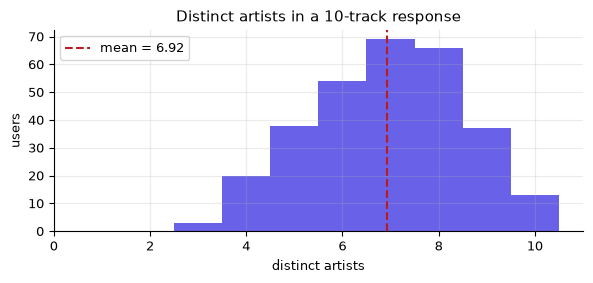

responses with 5 or fewer distinct artists: 20.3%


In [10]:
rng = np.random.default_rng(43)
sample_users = rng.choice(user_ids_artist, size=300, replace=False)

artists_per_response = []
for user_id in sample_users:
    picks, _ = recommend_v2(int(user_id), top_k=10)
    if picks:
        artists_per_response.append(len({track_to_artist.get(t, -1) for t in picks}))
artists_per_response = np.array(artists_per_response)

fig, ax = plt.subplots(figsize=(6, 2.9))
ax.hist(artists_per_response, bins=np.arange(0.5, 11.5, 1), color=ACCENT, alpha=0.85)
ax.axvline(artists_per_response.mean(), color=NEGATIVE, linestyle="--",
           label=f"mean = {artists_per_response.mean():.2f}")
ax.set_title("Distinct artists in a 10-track response")
ax.set_xlabel("distinct artists")
ax.set_ylabel("users")
ax.legend()
plt.tight_layout()
plt.show()

print(f"responses with 5 or fewer distinct artists: "
      f"{(artists_per_response <= 5).mean():.1%}")

### The candidate collection bug

The order of operations in stage 2a is wrong, and it is worth spelling out because the
consequence is counter-intuitive: it penalises the engine's most engaged users.

```python
for tid in self._artist_to_tracks.get(int(aidx), [])[:tracks_per_artist]:   # slice first
    if tid not in exclude:                                                  # filter second
        candidates.add(tid)
```

The slice runs before the filter, so an artist contributes candidates only from its ten
most popular tracks. Once a user has heard those ten, that artist contributes nothing -
regardless of how much of its catalogue remains. The engine's own `Manual.txt` gets this
right in pseudocode (`[t for t in artist_tracks if t not in seen_tracks]`, *then* sort
and slice); the shipped implementation inverted it.

In [11]:
sizes = np.array([len(v) for v in artist_tracks.values()])
deep = sizes > TRACKS_PER_ARTIST

print(f"artists with more than {TRACKS_PER_ARTIST} tracks: {deep.sum():,} "
      f"({deep.mean():.1%} of {len(sizes):,} artists with any track)")
print(f"tracks held by those artists: {sizes[deep].sum():,}")
print(f"reachable under the shipped code: {deep.sum() * TRACKS_PER_ARTIST:,}")
print(f"unreachable for a user who has heard the top 10: "
      f"{sizes[deep].sum() - deep.sum() * TRACKS_PER_ARTIST:,} tracks")
print()
print(f"largest catalogue: {sizes.max()} tracks, of which "
      f"{sizes.max() - TRACKS_PER_ARTIST} become unreachable")

artists with more than 10 tracks: 199 (5.6% of 3,545 artists with any track)
tracks held by those artists: 5,830
reachable under the shipped code: 1,990
unreachable for a user who has heard the top 10: 3,840 tracks

largest catalogue: 129 tracks, of which 119 become unreachable


### Tracks the engine cannot return at all

A second, larger reachability problem sits in the index construction. Any track absent
from `track_id_to_idx` is skipped while building `artist_tracks` - and that dictionary
is derived from the positive-reaction matrix, so it contains only tracks somebody has
already reacted to.

catalogue:                    14,843 tracks
reachable by the engine:      12,024
unreachable:                  2,819 (19.0%)

  of which, no reactions yet: 2,410
  of which, no known artist:  552


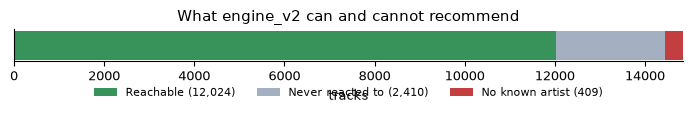

In [12]:
reachable = {t for tracks in artist_tracks.values() for t in tracks}
catalogue = set(int(t) for t in track_to_artist)

no_reactions = {t for t in catalogue if t not in track_id_to_idx}
unattributed = {t for t, a in track_to_artist.items() if artist_row.get(int(a)) is None}

print(f"catalogue:                    {len(catalogue):,} tracks")
print(f"reachable by the engine:      {len(reachable):,}")
print(f"unreachable:                  {len(catalogue - reachable):,} "
      f"({len(catalogue - reachable) / len(catalogue):.1%})")
print()
print(f"  of which, no reactions yet: {len(no_reactions):,}")
print(f"  of which, no known artist:  {len(unattributed):,}")

fig, ax = plt.subplots(figsize=(7, 1.7))
left = 0
for label, count, colour in [
    ("Reachable", len(reachable), POSITIVE),
    ("Never reacted to", len(no_reactions), MUTED),
    ("No known artist", len(catalogue - reachable) - len(no_reactions), NEGATIVE),
]:
    ax.barh([0], [count], left=left, color=colour, alpha=0.85, label=f"{label} ({count:,})")
    left += count
ax.set_xlim(0, len(catalogue))
ax.set_yticks([])
ax.grid(False)
ax.set_xlabel("tracks")
ax.set_title("What engine_v2 can and cannot recommend")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.5), ncol=3, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

2,410 tracks have never received a positive reaction, and the engine has no path to any
of them. For a tool whose stated purpose is surfacing songs a person has not heard, that
is the wrong 16% of the catalogue to be unable to reach.

## 4.7 Evaluation, and why the published numbers cannot be used

The training notebooks report a progression:

| configuration | Recall@10 | Precision@10 |
|---|---:|---:|
| artist model, no synthetic edges | 0.0808 | 0.0387 |
| artist model, with synthetic edges | 0.0874 | 0.0533 |
| full ensemble with track re-ranking | 0.1004 | 0.0751 |

The direction is plausible and the ensemble does appear to help. The numbers themselves
have four problems, and they compound.

**1. Popularity leaks across the split.** `track_pop` is computed as `mat.sum(axis=0)`
over the *entire* interaction matrix and then used to order candidates while evaluating
a held-out split. Every "most popular unseen track" decision during evaluation was made
with test data in hand.

**2. The artist model sees the test set.** The user-artist matrix is built from all track
reactions; only the *track* interactions are then split 80/20. Because a track's signal
is aggregated into its artist, stage 1 was trained on the artists of the exact tracks
stage 2 was later scored on surfacing.

**3. Hyperparameters were selected on the test set.** The grid sweep in
`engine_newer.ipynb` evaluates 390 configurations against the test split and reports the
best. There is no validation split.

**4. The reported metrics are mislabelled.** The sweep prints `Precision@10` while
computing `hits / TOP_K_FINAL` with `TOP_K_FINAL = 1`. `Summary.txt` then interprets a
Recall@1 of 0.038 as "the single recommended track is a real liked track about 7.6% of
the time", which does not follow from a recall figure. The two quantities are different,
and the difference is easy to demonstrate:

In [13]:
def recall_at_k(recommended, relevant, k):
    return len(set(recommended[:k]) & relevant) / len(relevant) if relevant else 0.0


def hit_rate_at_k(recommended, relevant, k):
    """The quantity 'is the track it gave me one I would have liked?' actually is."""
    return 1.0 if set(recommended[:k]) & relevant else 0.0


recommended = [101]
for n_relevant in (1, 2, 5, 20):
    relevant = {101} | set(range(900, 900 + n_relevant - 1))
    print(f"user has {n_relevant:2} liked tracks in the test set -> "
          f"recall@1 = {recall_at_k(recommended, relevant, 1):.3f}, "
          f"hit rate@1 = {hit_rate_at_k(recommended, relevant, 1):.1f}")

user has  1 liked tracks in the test set -> recall@1 = 1.000, hit rate@1 = 1.0
user has  2 liked tracks in the test set -> recall@1 = 0.500, hit rate@1 = 1.0
user has  5 liked tracks in the test set -> recall@1 = 0.200, hit rate@1 = 1.0
user has 20 liked tracks in the test set -> recall@1 = 0.050, hit rate@1 = 1.0


Recall@1 falls as a user's test set grows, even though the recommendation is identical
and correct every time. Averaged over users with widely differing history lengths, a
low Recall@1 says as much about the distribution of history lengths as about the
engine's quality - and it certainly cannot be read as a hit rate. The sweep's own
precision@1 for the recommended configuration is 0.1457, roughly four times the figure
the documentation quotes.

A further inconsistency: `Summary.md` claims "~11.1% Recall@10 and ~8.4% Precision@10",
while the notebook it describes printed 0.1004 and 0.0751.

### What the protocol should be

Tested implementations of the pieces below are in `engine RND/evaluation.py`.

1. Split each user's interactions individually, guaranteeing everyone keeps training
   data. A single global random mask can put a user's entire history in test.
2. Build the user-artist matrix from the **training** interactions only.
3. Compute popularity from the training interactions only.
4. Carve a validation split out of train; select on that, never on test.
5. Report recall@k, precision@k, hit rate@k, nDCG@k, catalogue coverage and Gini
   together, with `k` in the label.

Point 5 is not pedantry. Accuracy alone cannot distinguish a good recommender from one
that returns the popular head to everybody, and the popularity distribution from
Chapter 3 makes that a genuinely competitive strategy on this dataset.

## 4.8 Which parameters are actually running?

Four sources in the repository specify the two serving parameters, and they disagree:

| source | top artists | tracks per artist |
|---|---:|---:|
| `Manual.txt` section 4 | 5 | 1 |
| `Summary.txt` section 7 | 5 | 1 |
| `Summary.md` section 6 | 15 | 10 |
| `model_params/ensemble_config.json` | **20** | **10** |

The last is what the process reads, and it is the only one with no prose defending it.
It was also never measured: the sweep covered odd numbers of artists from 1 to 29.

In [14]:
swept_artist_counts = list(range(1, 31, 2))
shipped = config["n_artists_candidates"]
print(f"values of N_ARTISTS covered by the sweep: {swept_artist_counts}")
print(f"value shipped in ensemble_config.json:    {shipped}")
print(f"shipped value was measured:               {shipped in swept_artist_counts}")

values of N_ARTISTS covered by the sweep: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]
value shipped in ensemble_config.json:    20
shipped value was measured:               False


There is a deeper reproducibility problem behind this. `ensemble_config.json` records
1,310 artist-model users and 5,107 artists, but every training run whose output survives
in the notebooks printed **1,285 users and 4,919 artists**. The artifacts on the server
therefore came from a run that no longer exists in the repository - and nothing was
recorded that would let anyone reproduce it: no seed in the config, no data snapshot, no
training date, no fingerprint.

In [15]:
print(f"ensemble_config.json : {config['n_users_artist']:,} users, "
      f"{config['n_artists']:,} artists, genre_dim {config['genre_dim']}")
print(f"shipped arrays       : {artist_user_emb.shape[0]:,} users, "
      f"{artist_item_emb.shape[0]:,} artists, genre_dim {genre_features.shape[1]}")
print(f"notebook run output  : 1,285 users, 4,919 artists  <- does not match")

ensemble_config.json : 1,310 users, 5,107 artists, genre_dim 373
shipped arrays       : 1,310 users, 5,107 artists, genre_dim 373
notebook run output  : 1,285 users, 4,919 artists  <- does not match


## 4.9 Deployment

The engine runs as its own process, with its own virtual environment, entirely separate
from the main application.

```mermaid
flowchart LR
    TG["Telegram Mini App"] --> WEB["FastAPI webapp<br/>app/webapp/"]
    WEB -->|"httpx, 5s timeout"| CLIENT["engine_client.py"]
    CLIENT -->|"GET 127.0.0.1:8100"| ENGINE["Recommendation engine<br/>own process, own venv"]
    ENGINE --> PARAMS[("model_params/<br/>static between retrains")]
    WEB --> DB[("PostgreSQL")]
    CLIENT -.->|"None on any failure"| FALLBACK["In-house heuristic<br/>repository.suggest_track_for_user"]
```

Four endpoints, all `GET`, all JSON:

| endpoint | returns |
|---|---|
| `/health` | liveness plus loaded user/artist/track counts |
| `/suggest` | one next-track pick with a human-readable reason |
| `/recommend` | a ranked batch of `top_k` track ids |
| `/onboarding` | cold-start tracks from several popular artists |

Three properties of this arrangement are worth naming, because they are all deliberate
and all correct:

- **Loopback only.** The engine binds `127.0.0.1` and has no authentication of its own.
  The binding is the entire security boundary.
- **Stateless.** No database access. The application passes in whatever signal it has -
  reacted artists, tracks already seen - on each call.
- **Fails soft.** `engine_client.py` returns `None` on any error rather than raising, so
  the webapp silently falls back to its own heuristic. The recommendation engine being
  down degrades suggestions; it does not take the app with it.

Deployment is a separate GitHub Actions workflow (`deploy-engine.yml`) that watches
`engine_v*/**`, picks the highest changed version, rsyncs it into the server's single
`engine/` folder and restarts a dedicated systemd user unit. The app stack and the
engine can therefore be deployed independently.

Two operational weak points, both fixed in the revised build:

- `deploy/start.sh` runs `pip install --upgrade` on every restart, so a routine restart
  depends on PyPI being reachable - for pinned dependencies that are already installed.
- If the model files fail to load, the failure happens inside the lifespan handler and
  every subsequent request fails with a `KeyError` on the missing state. There is no
  degraded mode and no way to ask the process what went wrong.

## 4.10 The review, and what came out of it

Reviewing the pipeline end to end produced about thirty findings. Twelve concern the
serving path, five the evaluation, five the training, two the cleaning stage, and nine
are operational. The revised engine in `engine RND/` fixes everything that can be fixed
without retraining and documents the rest as a protocol.

The main changes:

| | `engine_v2` | `engine RND` |
|---|---|---|
| Candidate collection | truncate, then exclude | exclude, then truncate |
| Empty pool | straight to global popularity | widen the shortlist x2, x4, x8 first |
| Stage-1 score | dot product only | dot product + recovered artist bias, weighted |
| Zero-reaction tracks | unreachable | eligible candidates |
| Candidates with no embedding | dropped | scored by popularity prior |
| Repeated artists | unconstrained | per-response cap and session-level damping |
| Live reactions for a known user | discarded | blended with the trained vector |
| `/suggest` | deterministic forever | softmax-over-rank sampling |
| Artifact validation | none | 8 consistency checks at load |
| Failed load | 500 on every request | `/health` reports degraded, endpoints 503 |
| Serving dependencies | + scikit-learn, 4 pickles | numpy only, no pickles |
| Tests | none | 99 |

Measured over 300 users with 20 consecutive requests each, exclusions accumulating,
each engine driven through its own `/suggest` path:

| | `engine_v2` | `engine RND` |
|---|---:|---:|
| Distinct artists in a 10-track response | 6.95 | 7.74 |
| Distinct artists over a 20-track session | 11.25 | 14.48 |
| Requests falling through to popularity | 0.07% | 0.00% |
| Catalogue coverage across all sessions | 12.86% | 14.07% |
| Exposure Gini | 0.545 | 0.523 |
| Tracks the algorithm can ever return | 12,024 | 14,291 |
| Latency p50 | 0.27 ms | 0.40 ms |

Reproduce with `python "engine RND/tools/benchmark.py" --users 300 --session-length 20`.

No accuracy comparison appears in that table, deliberately: producing a trustworthy one
requires the raw interaction CSVs and a retrain under the protocol in section 4.7, and
quoting `engine_v2`'s published figures as a baseline would mean quoting numbers this
chapter has just explained are unsound.

## Summary

**The architecture is right.** On a matrix that is 0.55% dense with a median of four
reactions per track, ranking artists first and using the track model only to order a
short candidate list is the correct response to the data. Adding genre features as a
side channel to the artist model is the correct way to say something about artists with
no interactions.

**The implementation had specific, findable defects.** Candidate truncation ran before
exclusion, penalising the most engaged users. A sixth of the catalogue was structurally
unreachable. The trained artist bias was never exported, so serving optimised a
different function than training. Nothing constrained artist diversity, and the
engine's own notebook output shows the consequence.

**The evaluation cannot support the conclusions drawn from it.** Popularity leaked
across the split, the artist model saw the test set, hyperparameters were selected on
test, and the headline figure was misread as a quantity it is not. The reported numbers
are not necessarily wrong in direction - the ensemble almost certainly does beat the
artist model alone - but their magnitudes should not be quoted.

**What is still open.** Whether the revised engine recommends *better* tracks, as
opposed to more varied ones from more of the catalogue, is unresolved and needs a
retrain under a leakage-free protocol. Item cold start remains the most valuable
unexplored piece of modelling work: the genre matrix already helps cold-start artists,
and the same idea applied to tracks would address the 2,410 tracks the collaborative
signal says nothing about.

The full review is in [`engine RND/ANALYSIS.md`](../engine%20RND/ANALYSIS.md).